In [1]:
import pymc as pm
import arviz as az
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os 
az.style.use("arviz-darkgrid")

In [ ]:
monomer_trace = "1_ep_test_summary.nc"
monomer_trace = az.from_netcdf(monomer_trace)
trace = "1.nc"
trace = az.from_netcdf(trace)

In [2]:
az.plot_trace_dist(trace, compact=True)
az.combine_plots(trace, plots= [(az.plot_rank, {"thin": False}), (az.plot_autocorr, {}), (az.plot_ess, {})])

NameError: name 'trace' is not defined

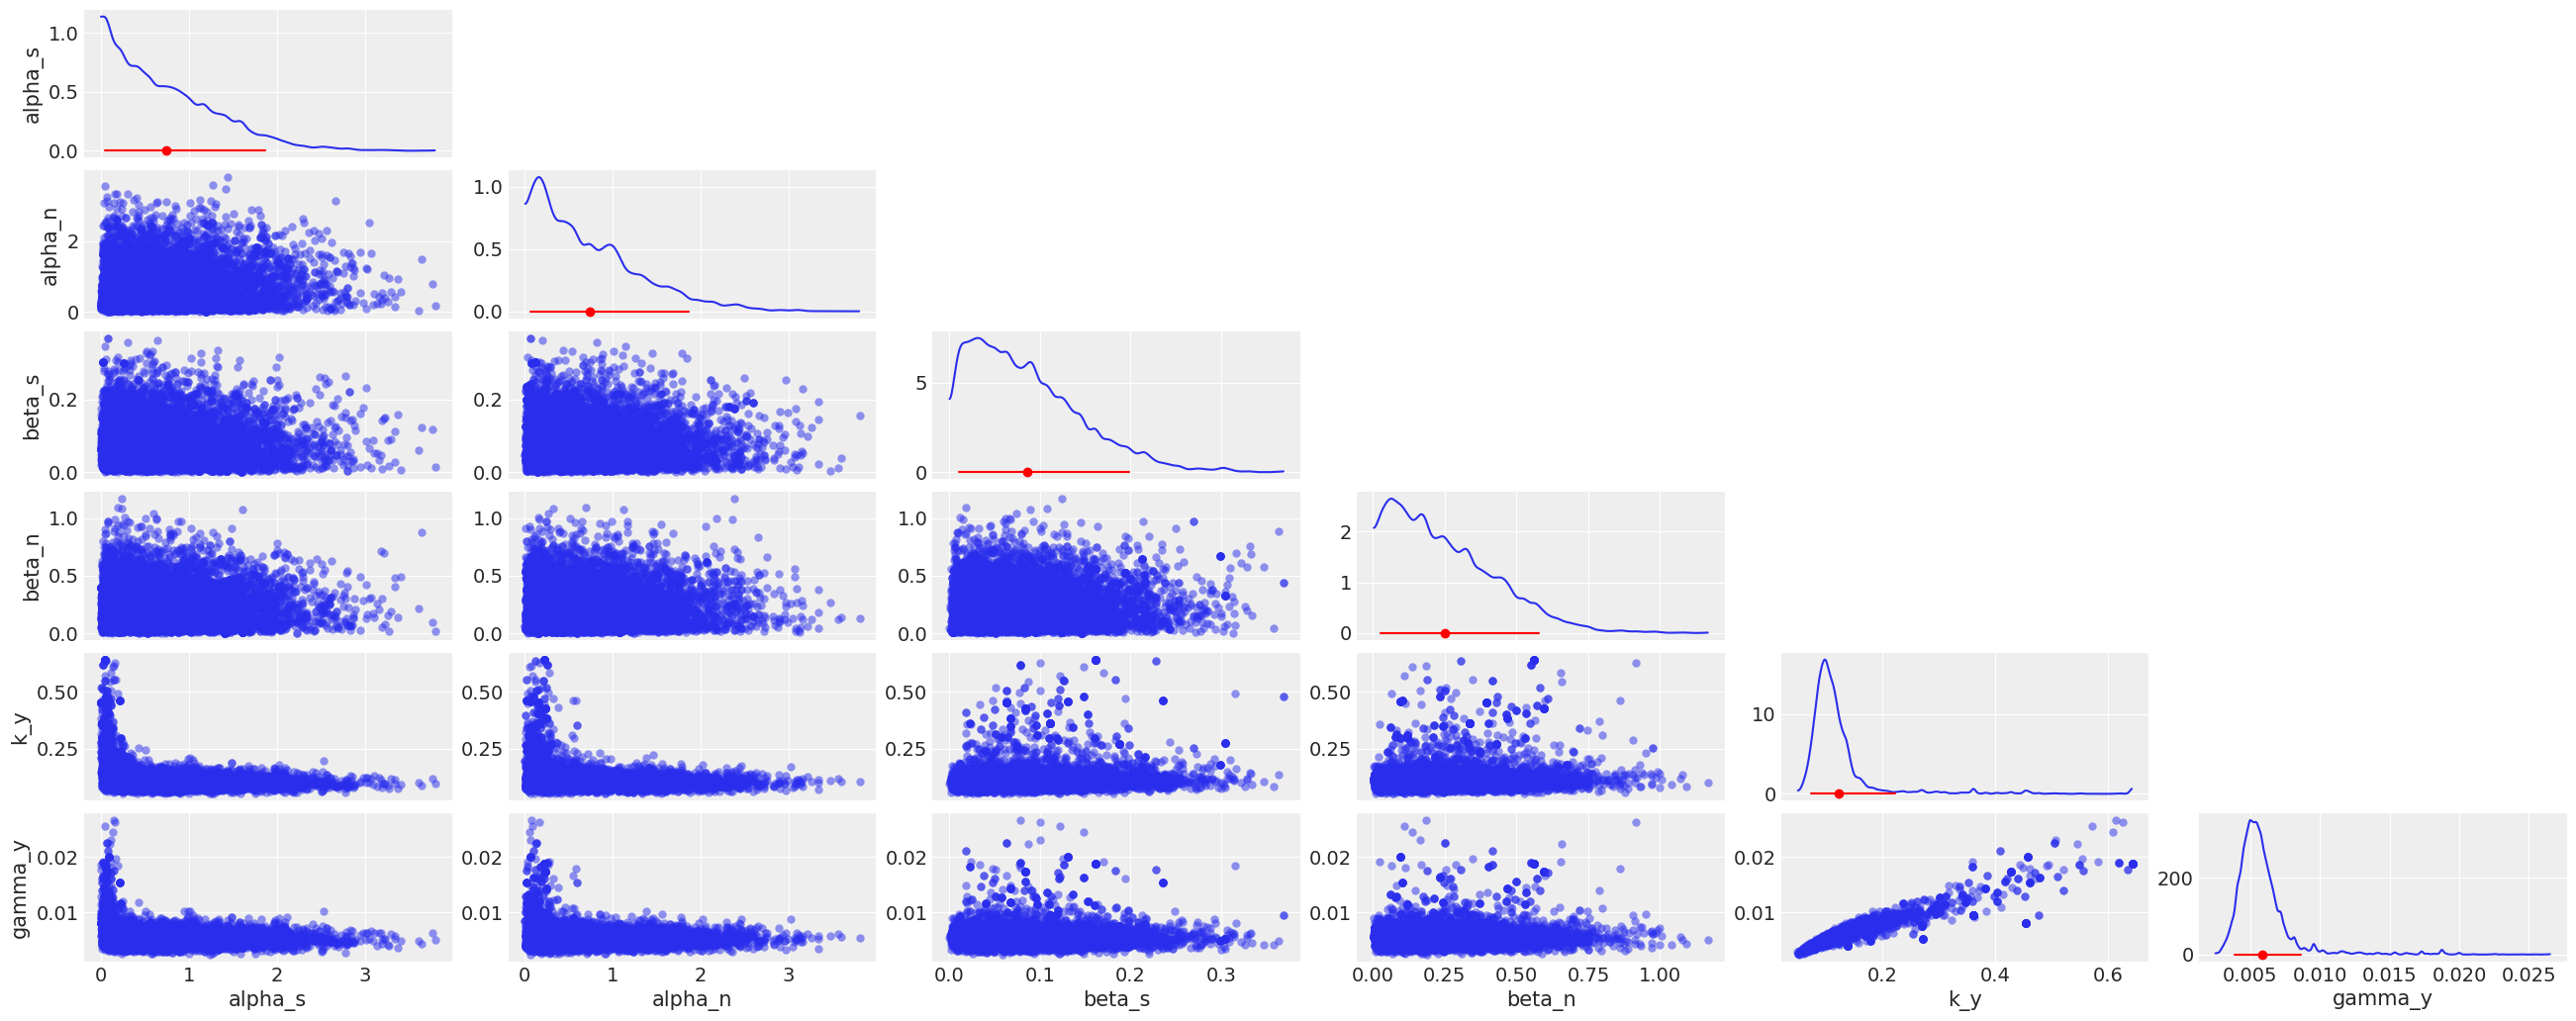

In [ ]:
visuals = {"credible_interval":{"color":"red"},"point_estimate":{"color":"red"}}
az.plot_pair(trace, group="posterior", visuals=visuals)


KeyError: "No variable named 'group'. Variables on the dataset include ['alpha_s', 'alpha_n', 'beta_s', 'beta_n', 'k_y', 'gamma_y', 'column']"

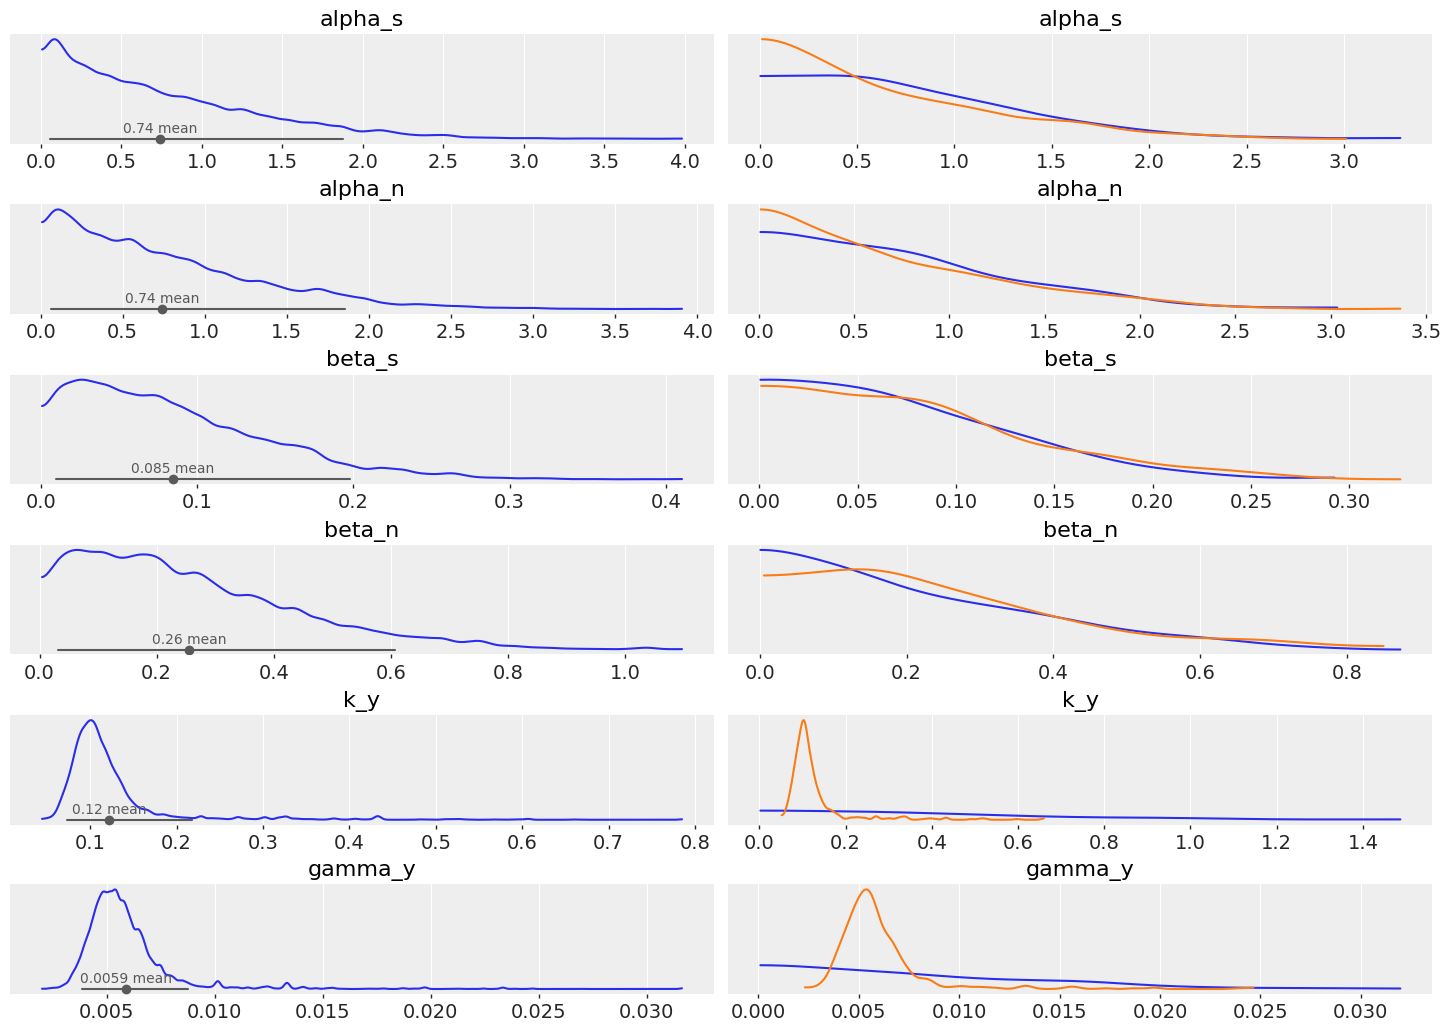

In [4]:
az.combine_plots(trace, plots= [(az.plot_dist, {}), (az.plot_prior_posterior, {})])

In [100]:

az.summary(trace, kind="all")



,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha_s,0.74,0.61,0.058,1.9,2218,1435,1.00,0.011,0.0092
alpha_n,0.74,0.59,0.065,1.9,2978,2339,1.00,0.0095,0.0084
beta_s,0.085,0.061,0.0099,0.2,3435,3222,1.00,0.00099,0.00082
beta_n,0.256,0.186,0.032,0.61,3312,2903,1.00,0.0033,0.0028
k_y,0.122,0.07,0.073,0.22,2522,1429,1.00,0.0021,0.005
gamma_y,0.0059,0.0022,0.0039,0.0088,2789,1493,1.00,5.8e-05,0.00015


In [106]:
az.mcse(trace)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:  ()
    Data variables:
        alpha_s  float64 8B 0.01038
        alpha_n  float64 8B 0.009592
        beta_s   float64 8B 0.001008
        beta_n   float64 8B 0.003187
        k_y      float64 8B 0.002251
        gamma_y  float64 8B 5.847e-05

c:\Users\danie\miniconda3\envs\pymc_env\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\danie\miniconda3\envs\pymc_env\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


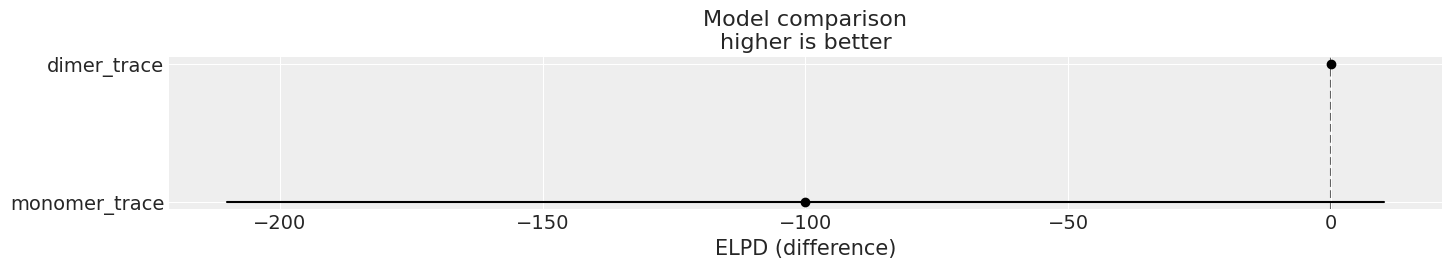

In [74]:
compare = az.compare(compare_dict={"dimer_trace": dimer_trace, "monomer_trace": monomer_trace})
az.plot_compare(compare)

In [107]:
az.psense_summary(trace, round_to=2)


We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
alpha_s,0.22,0.04,potential strong prior / weak likelihood
alpha_n,0.23,0.05,potential strong prior / weak likelihood
beta_s,0.24,0.07,potential prior-data conflict
beta_n,0.24,0.11,potential prior-data conflict
k_y,0.15,0.11,potential prior-data conflict
gamma_y,0.12,0.14,potential prior-data conflict


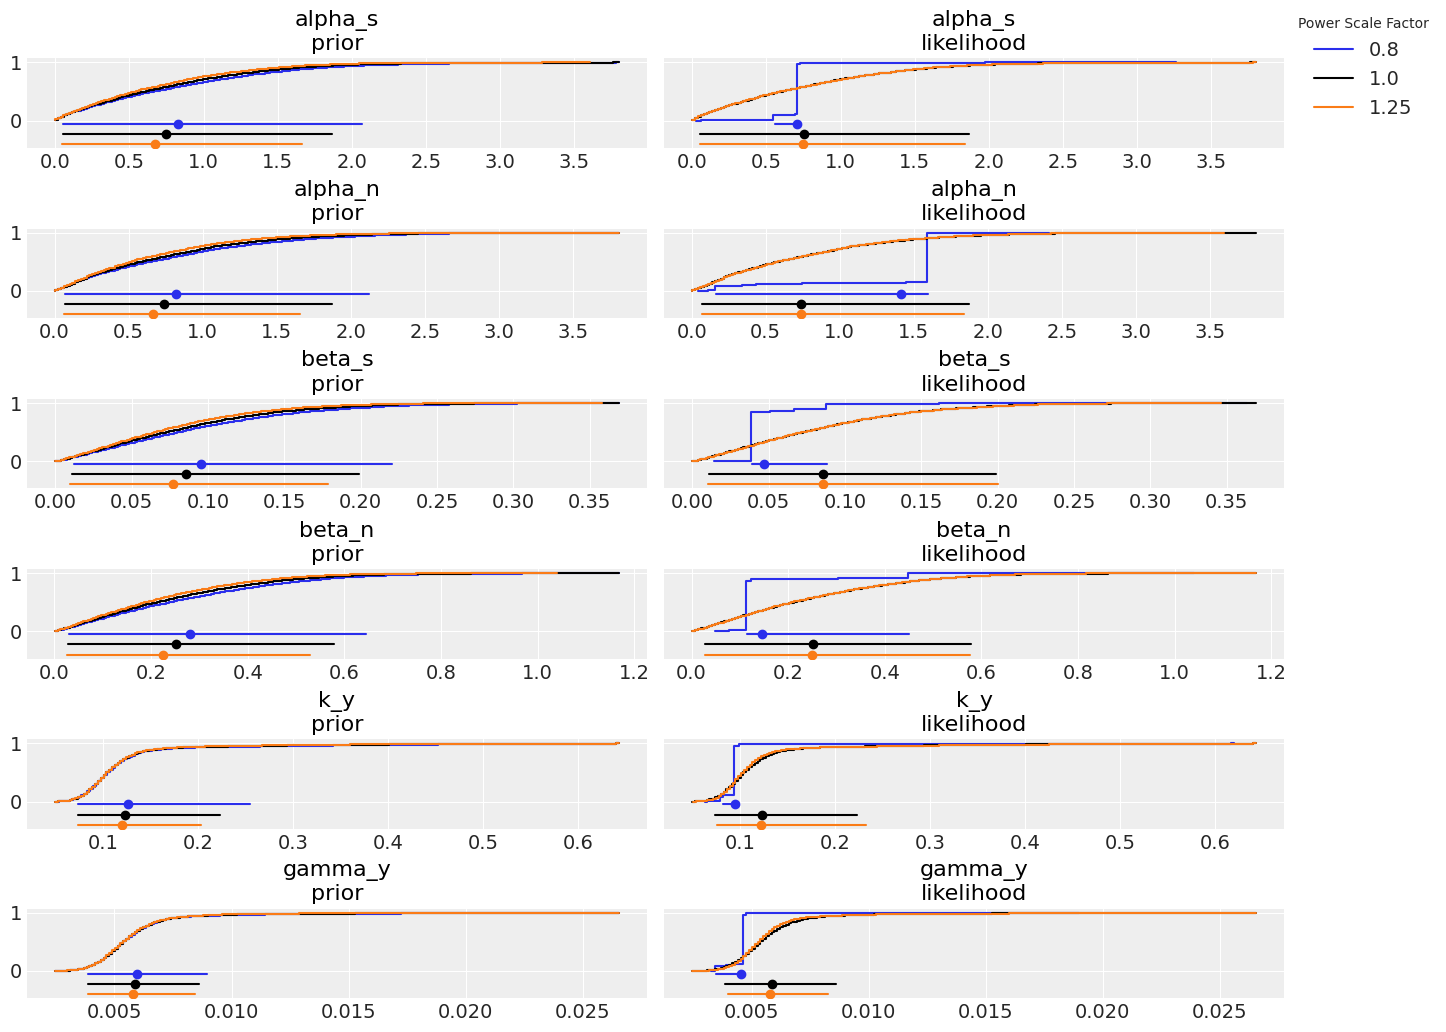

In [108]:
az.plot_psense_dist(trace, kind="ecdf")

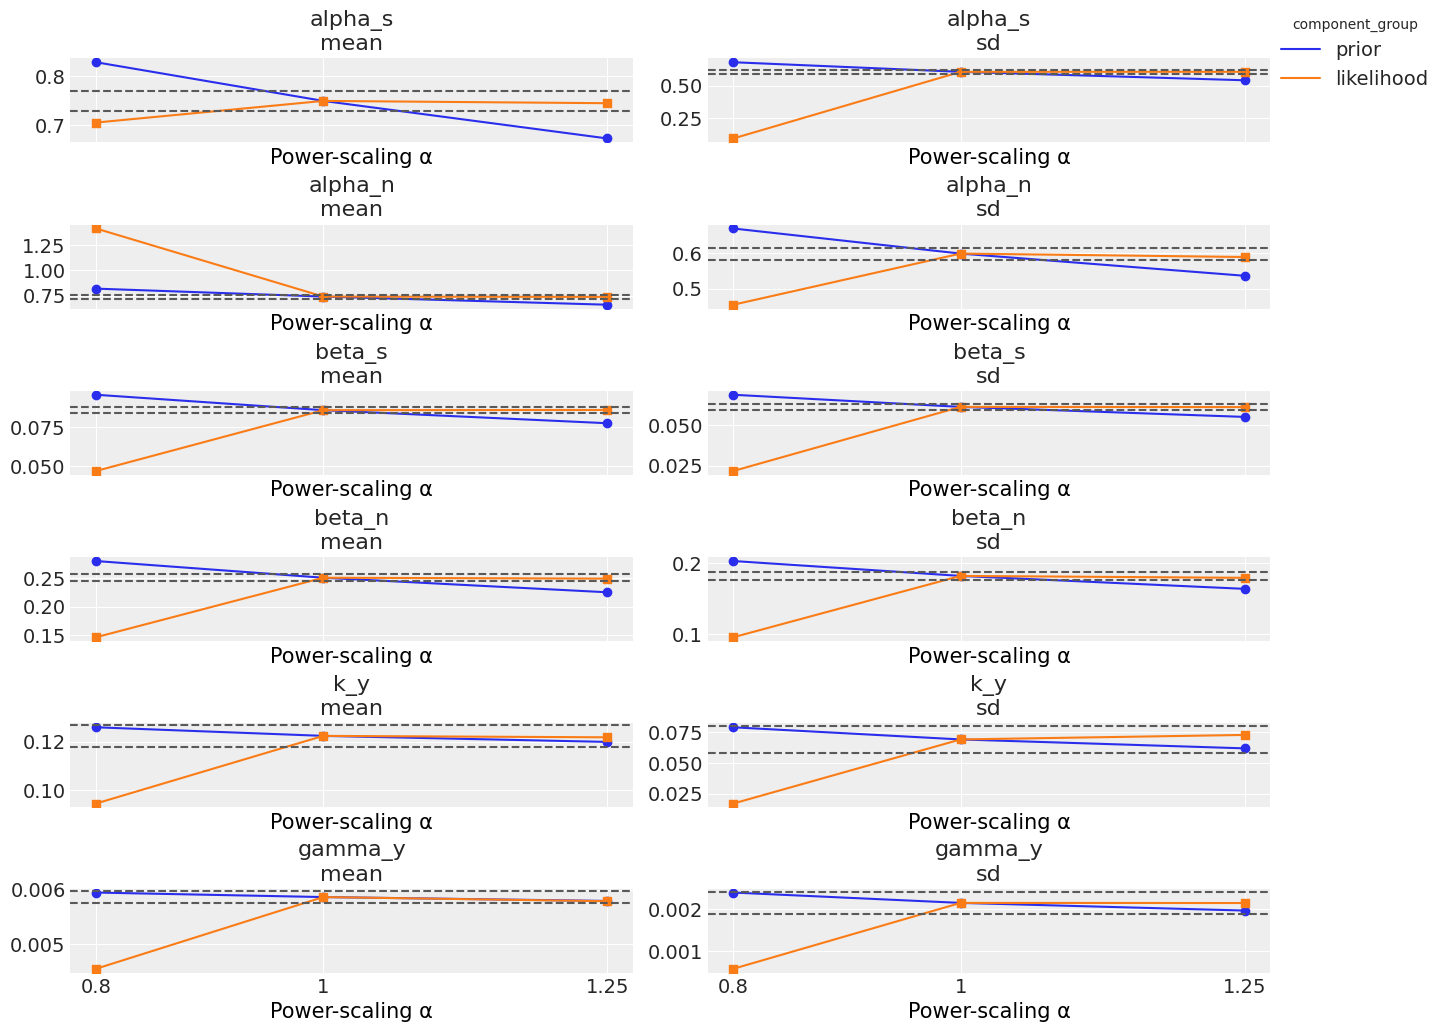

In [109]:
az.plot_psense_quantities(trace)

In [79]:
az.plot_ecdf_pit(trace)

KeyError: 'Could not find node at prior_sbc'

In [80]:
monomer_evidence = monomer_trace.sample_stats["log_marginal_likelihood"].values[-1]
dimer_evidence = dimer_trace.sample_stats["log_marginal_likelihood"].values[-1]
print(f"Monomer log-evidence: {monomer_evidence}")
print(f"Dimer log-evidence: {dimer_evidence}")


Monomer log-evidence: [        nan         nan         nan         nan         nan         nan
 -9.30682092]
Dimer log-evidence: [        nan         nan -3.81974033]


ValueError: Keyword arguments ['divergences', 'divergences_kwargs'] have been passed as **kwargs but have no active aesthetic mapped to them. Keyword arguments must define values to use in their respective aesthetic mapping.

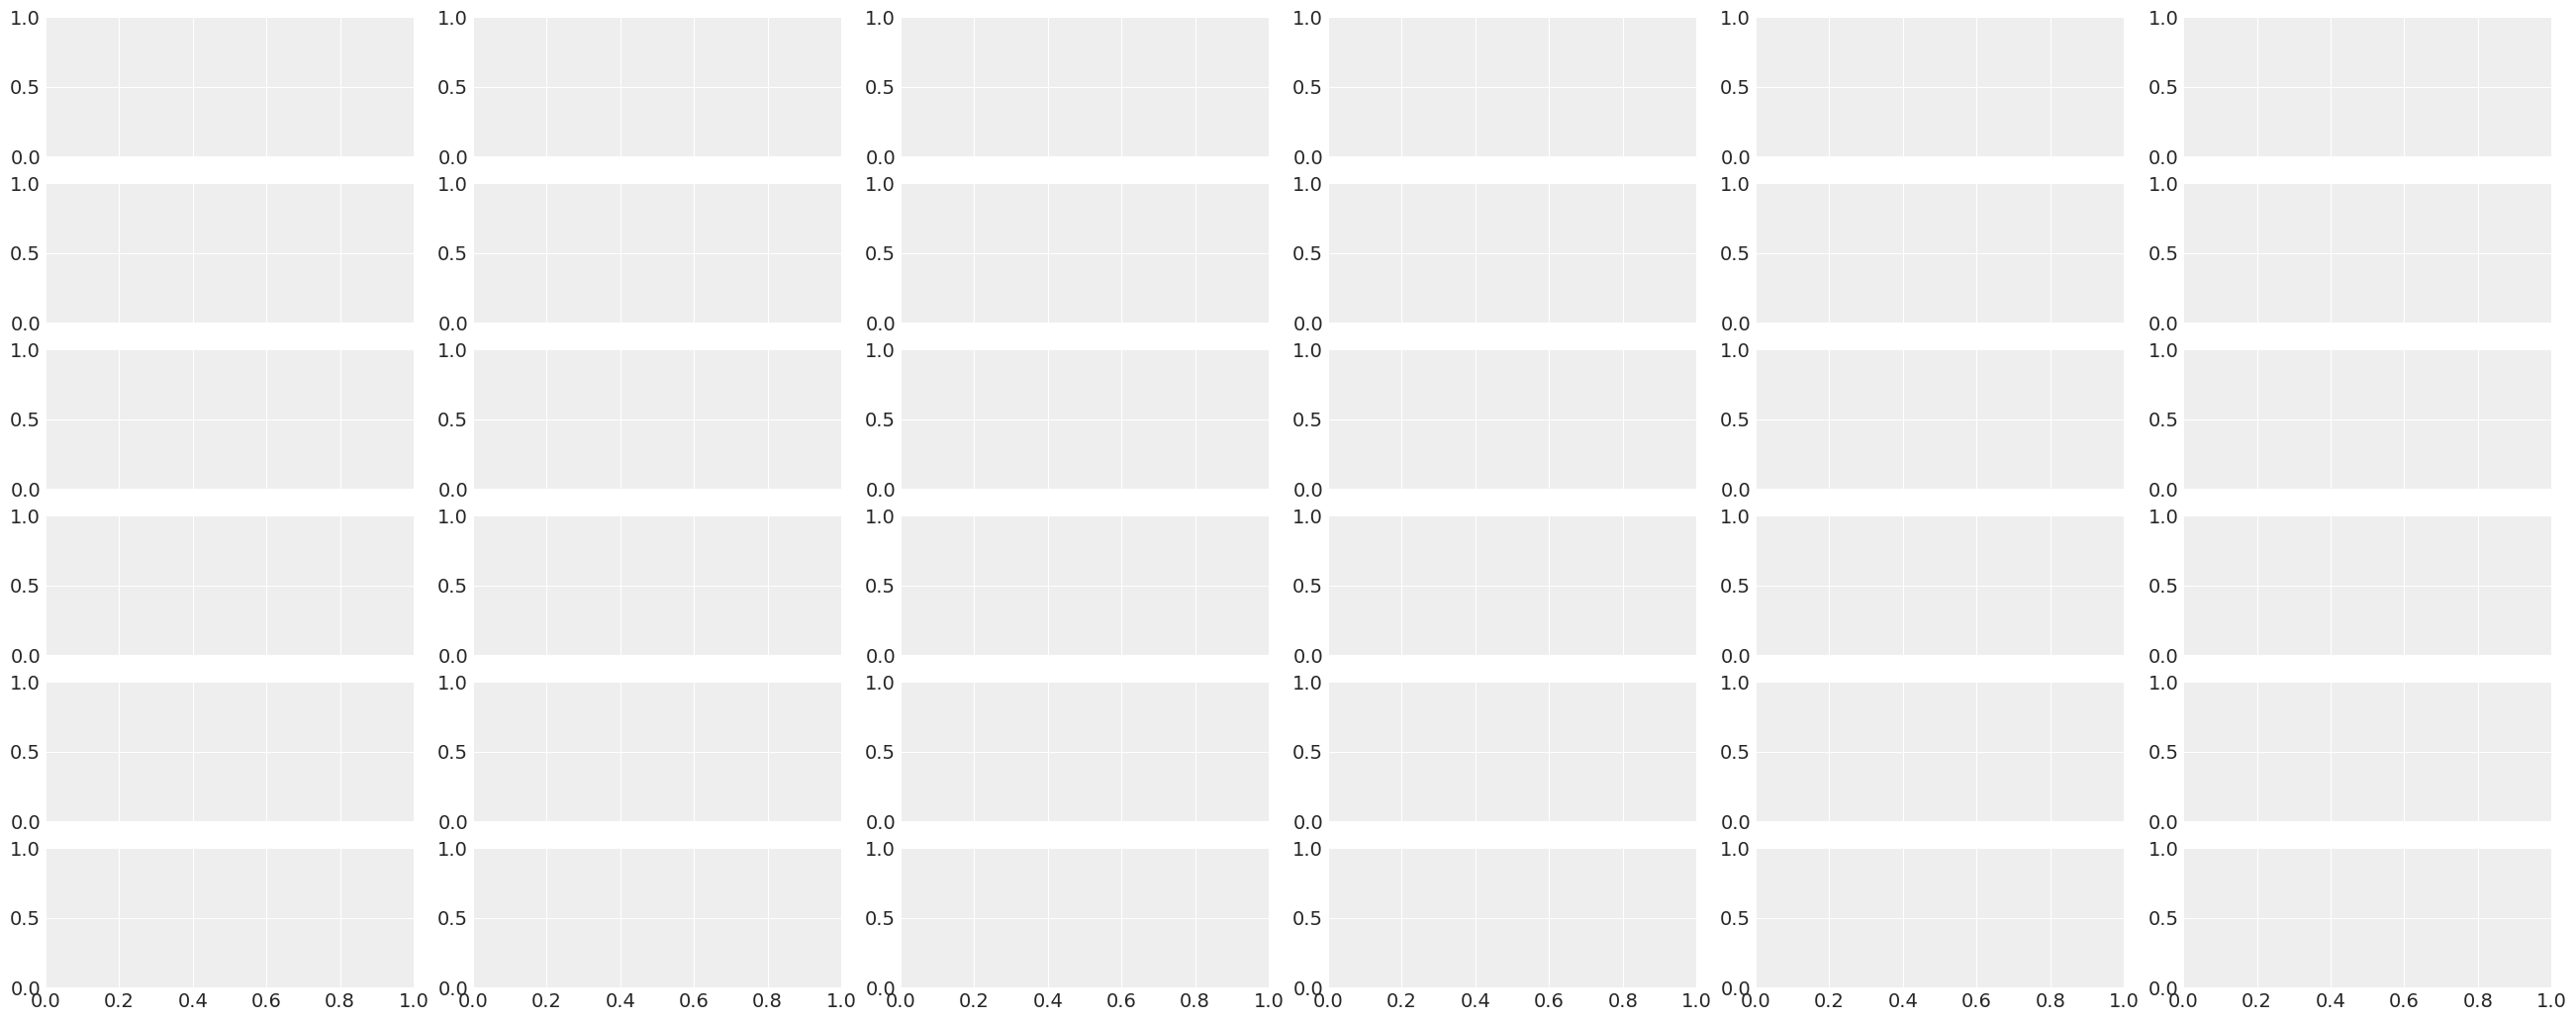

In [87]:
az.plot_pair(
    trace,
    divergences=True,
    divergences_kwargs={"color": "red", "alpha": 0.8}
)